In [1]:
!pip install timm --quiet

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# Seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [11]:
# Image size for ViT (pretrained on 224x224)
img_size = 224

from torchvision.transforms import RandAugment
from timm.data.mixup import Mixup
from timm.loss import SoftTargetCrossEntropy  # for Mixup's soft labels

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),  # more aggressive scaling
    transforms.RandomHorizontalFlip(),
    RandAugment(num_ops=2, magnitude=9),                  # strong augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation / test transforms (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Full datasets
full_train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=eval_transform)

In [12]:
mixup_fn = Mixup(mixup_alpha=0.8, cutmix_alpha=1.0, prob=0.5, num_classes=10)

In [13]:
# Extract all targets
targets = np.array(full_train_set.targets)
classes = np.unique(targets)

train_indices = []
val_indices = []
samples_per_class = 100

for cls in classes:
    cls_indices = np.where(targets == cls)[0]
    # Shuffle and pick 100
    np.random.shuffle(cls_indices)
    selected = cls_indices[:samples_per_class + samples_per_class]
    # Split into train and validation
    n_val = int(samples_per_class)
    val_indices.extend(selected[:samples_per_class])
    train_indices.extend(selected[samples_per_class:])

# Create subset datasets with their respective transforms
train_subset = Subset(full_train_set, train_indices)
val_subset = Subset(full_train_set, val_indices)

# Override the transforms (important: Subset uses the original dataset's transform)
train_subset.dataset.transform = train_transform
val_subset.dataset.transform = eval_transform

print(f'Train samples: {len(train_subset)}, Val samples: {len(val_subset)}')

Train samples: 1000, Val samples: 1000


In [14]:
batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=4)

In [18]:
model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=10, drop_rate=0.2, 
                         drop_path_rate=0.1)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params / 1e6:.2f}M')

Total parameters: 21.67M


In [ ]:
import math
from torch.optim.lr_scheduler import LambdaLR

criterion = SoftTargetCrossEntropy()

# Separate backbone and head
head_params = list(model.head.parameters())
backbone_params = [p for n, p in model.named_parameters() if 'head' not in n]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 3e-5, 'weight_decay': 1e-2},   # 10x lower LR
    {'params': head_params,     'lr': 3e-4, 'weight_decay': 1e-2}
])

# Warmup + cosine schedule
total_epochs = 50          # longer training with strong aug
num_epochs = total_epochs
warmup_epochs = 5

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        # linear increase from 0 to 1
        return float(epoch + 1) / float(warmup_epochs)
    else:
        # cosine annealing from 1 down to 0
        progress = float(epoch - warmup_epochs) / float(total_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

In [25]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # ------------------ Training ------------------
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for images, labels in loop:
        images, labels_orig = images.to(device), labels.to(device)   # keep original labels
        images, labels_mixed = mixup_fn(images, labels_orig)          # apply mixup
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_mixed)                      # soft-target loss
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        # Compute accuracy using the ORIGINAL hard labels
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_orig).sum().item()
        total += labels_orig.size(0)
        
        loop.set_postfix(loss=loss.item(), acc=correct/total)
    
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    
    # ------------------ Validation ------------------
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # Use standard CrossEntropyLoss for hard labels (no mixup)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_val_loss = running_loss / total
    epoch_val_acc = correct / total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    
    print(f'Epoch {epoch+1}: Train Loss={epoch_train_loss:.4f}, Train Acc={epoch_train_acc:.4f} | Val Loss={epoch_val_loss:.4f}, Val Acc={epoch_val_acc:.4f}')
    
    scheduler.step()

Epoch 1/30 [Val]: 100%|██████████| 16/16 [00:03<00:00,  4.11it/s]


Epoch 1: Train Loss=0.7649, Train Acc=0.9130 | Val Loss=0.3527, Val Acc=0.9250


Epoch 2/30 [Val]: 100%|██████████| 16/16 [00:04<00:00,  3.85it/s]


Epoch 2: Train Loss=0.8686, Train Acc=0.8860 | Val Loss=0.3696, Val Acc=0.9240


Epoch 3/30 [Val]: 100%|██████████| 16/16 [00:03<00:00,  4.13it/s]


...

Epoch 28: Train Loss=0.8140, Train Acc=0.8130 | Val Loss=0.3711, Val Acc=0.9260


Epoch 29/30 [Val]: 100%|██████████| 16/16 [00:03<00:00,  4.17it/s]


Epoch 29: Train Loss=0.8080, Train Acc=0.8640 | Val Loss=0.3455, Val Acc=0.9260


Epoch 30/30 [Val]: 100%|██████████| 16/16 [00:03<00:00,  4.17it/s]

Epoch 30: Train Loss=0.8527, Train Acc=0.8500 | Val Loss=0.3504, Val Acc=0.9280


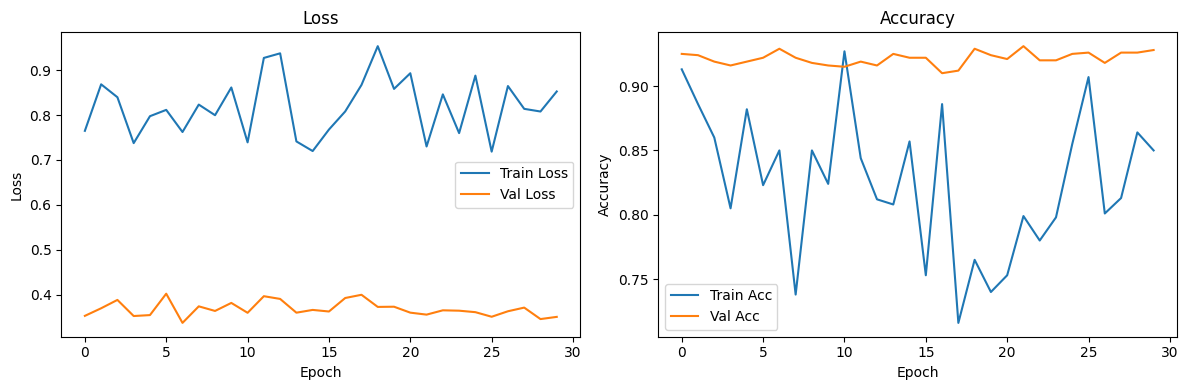

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.tight_layout()
plt.show()

In [27]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f'Final Test Accuracy (full test set): {test_acc:.4f} ({test_acc*100:.2f}%)')

Testing: 100%|██████████| 157/157 [00:35<00:00,  4.45it/s]

Final Test Accuracy (full test set): 0.9211 (92.11%)


In [29]:
torch.save(model, 'teacher_vit_small_full.pth')